# Multivariate Plots Examples

This notebook demonstrates the usage of the MultivariatePlots class methods with simple sklearn datasets.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris, load_wine, load_diabetes, load_breast_cancer
from kvbiii_plots.eda import MultivariatePlots

/home/kvbiii/Programming/Python/Paczki/kvbiii-plots/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
multi_plots = MultivariatePlots()

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]
iris_df['target'] = iris.target

wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['wine_class'] = wine.target_names[wine.target]
wine_df['target'] = wine.target

diabetes = load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target

cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df['diagnosis'] = cancer.target_names[cancer.target]
cancer_df['target'] = cancer.target

print("Datasets loaded:")
print(f"Iris: {iris_df.shape}")
print(f"Wine: {wine_df.shape}")
print(f"Diabetes: {diabetes_df.shape}")
print(f"Breast Cancer: {cancer_df.shape}")

Datasets loaded:
Iris: (150, 6)
Wine: (178, 15)
Diabetes: (442, 11)
Breast Cancer: (569, 32)


## 2. correlation_plot() - Correlation Analysis

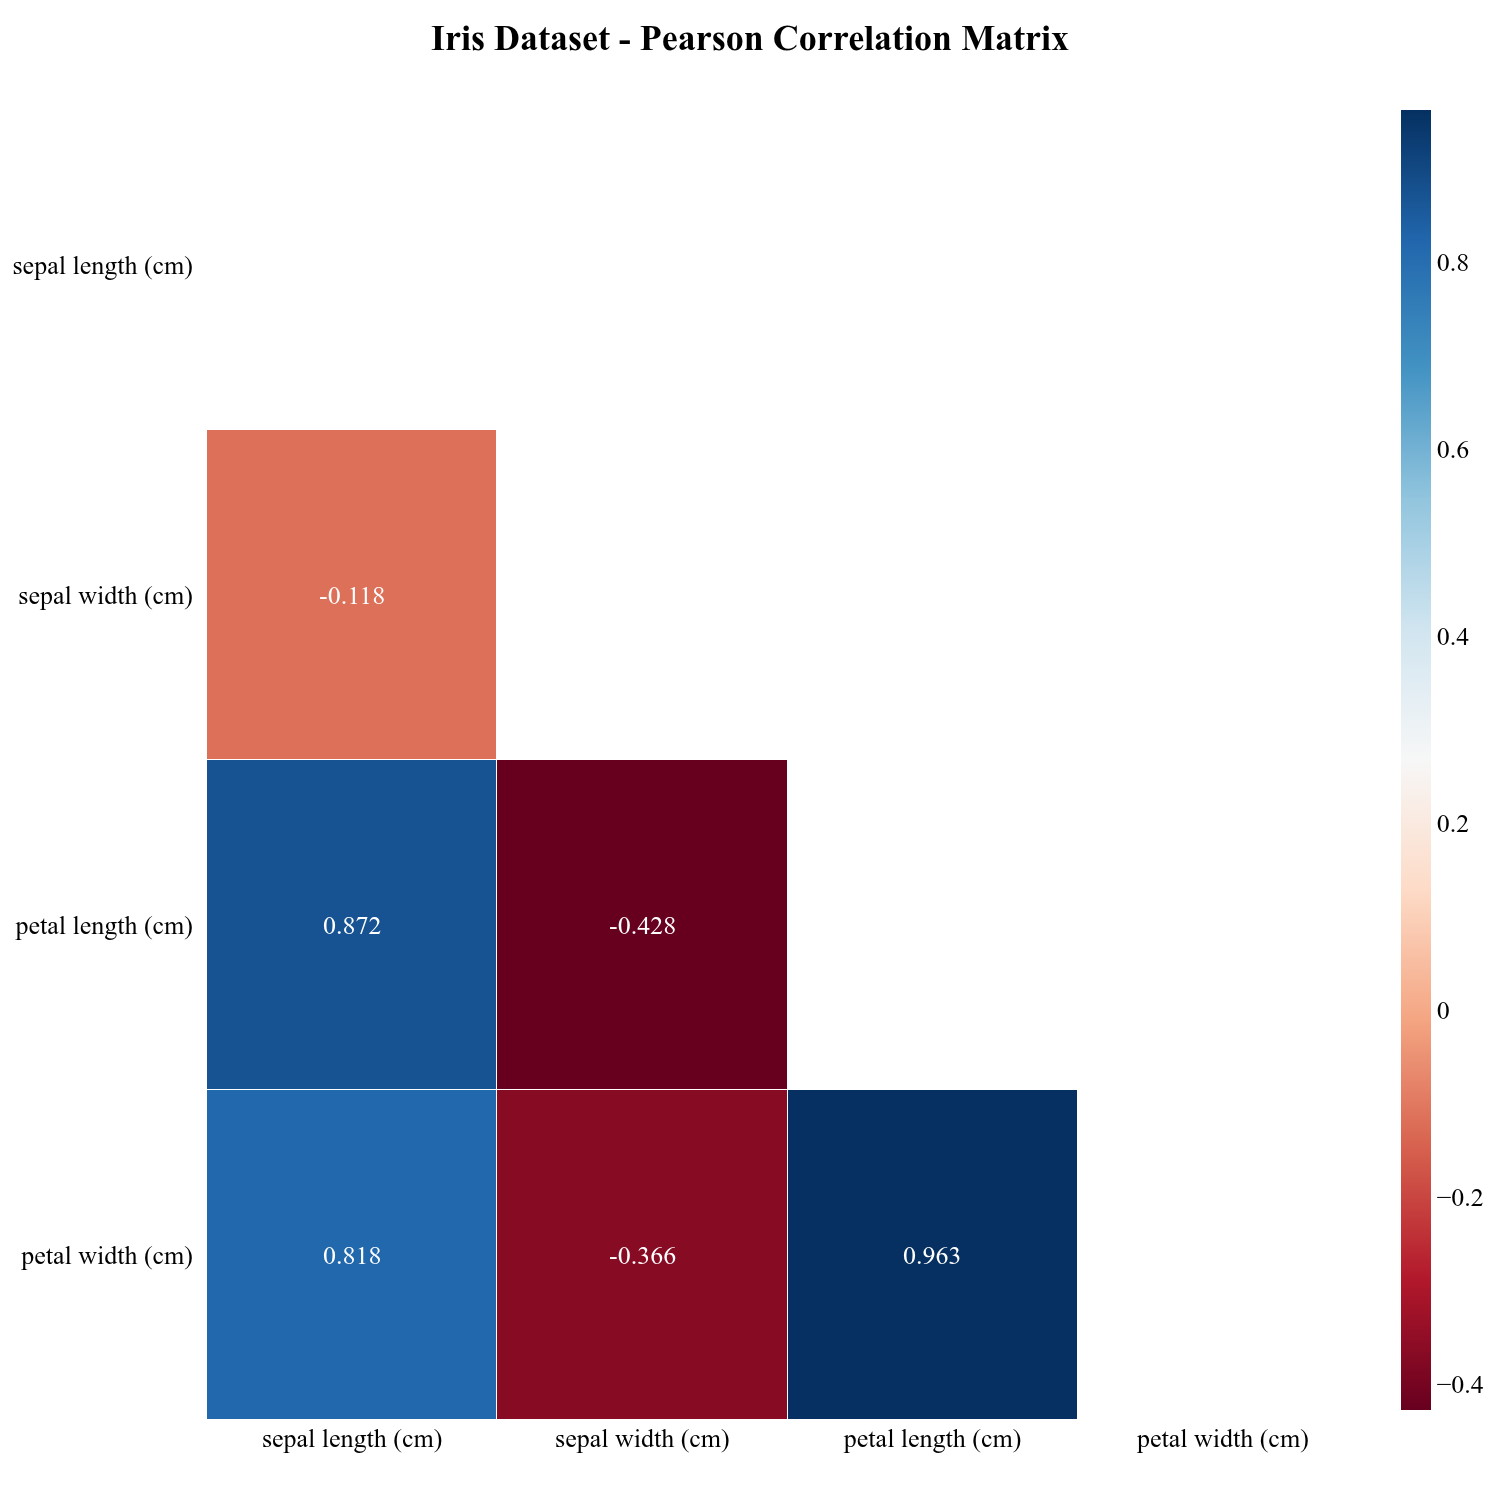

In [3]:
multi_plots.correlation_plot(
    data=iris_df[iris.feature_names],
    features_names=list(iris.feature_names),
    method='pearson',
    plot_title="Iris Dataset - Pearson Correlation Matrix",
    width=1500,
    height=1500,
    show_upper=False,
    colorscale="RdBu"
)

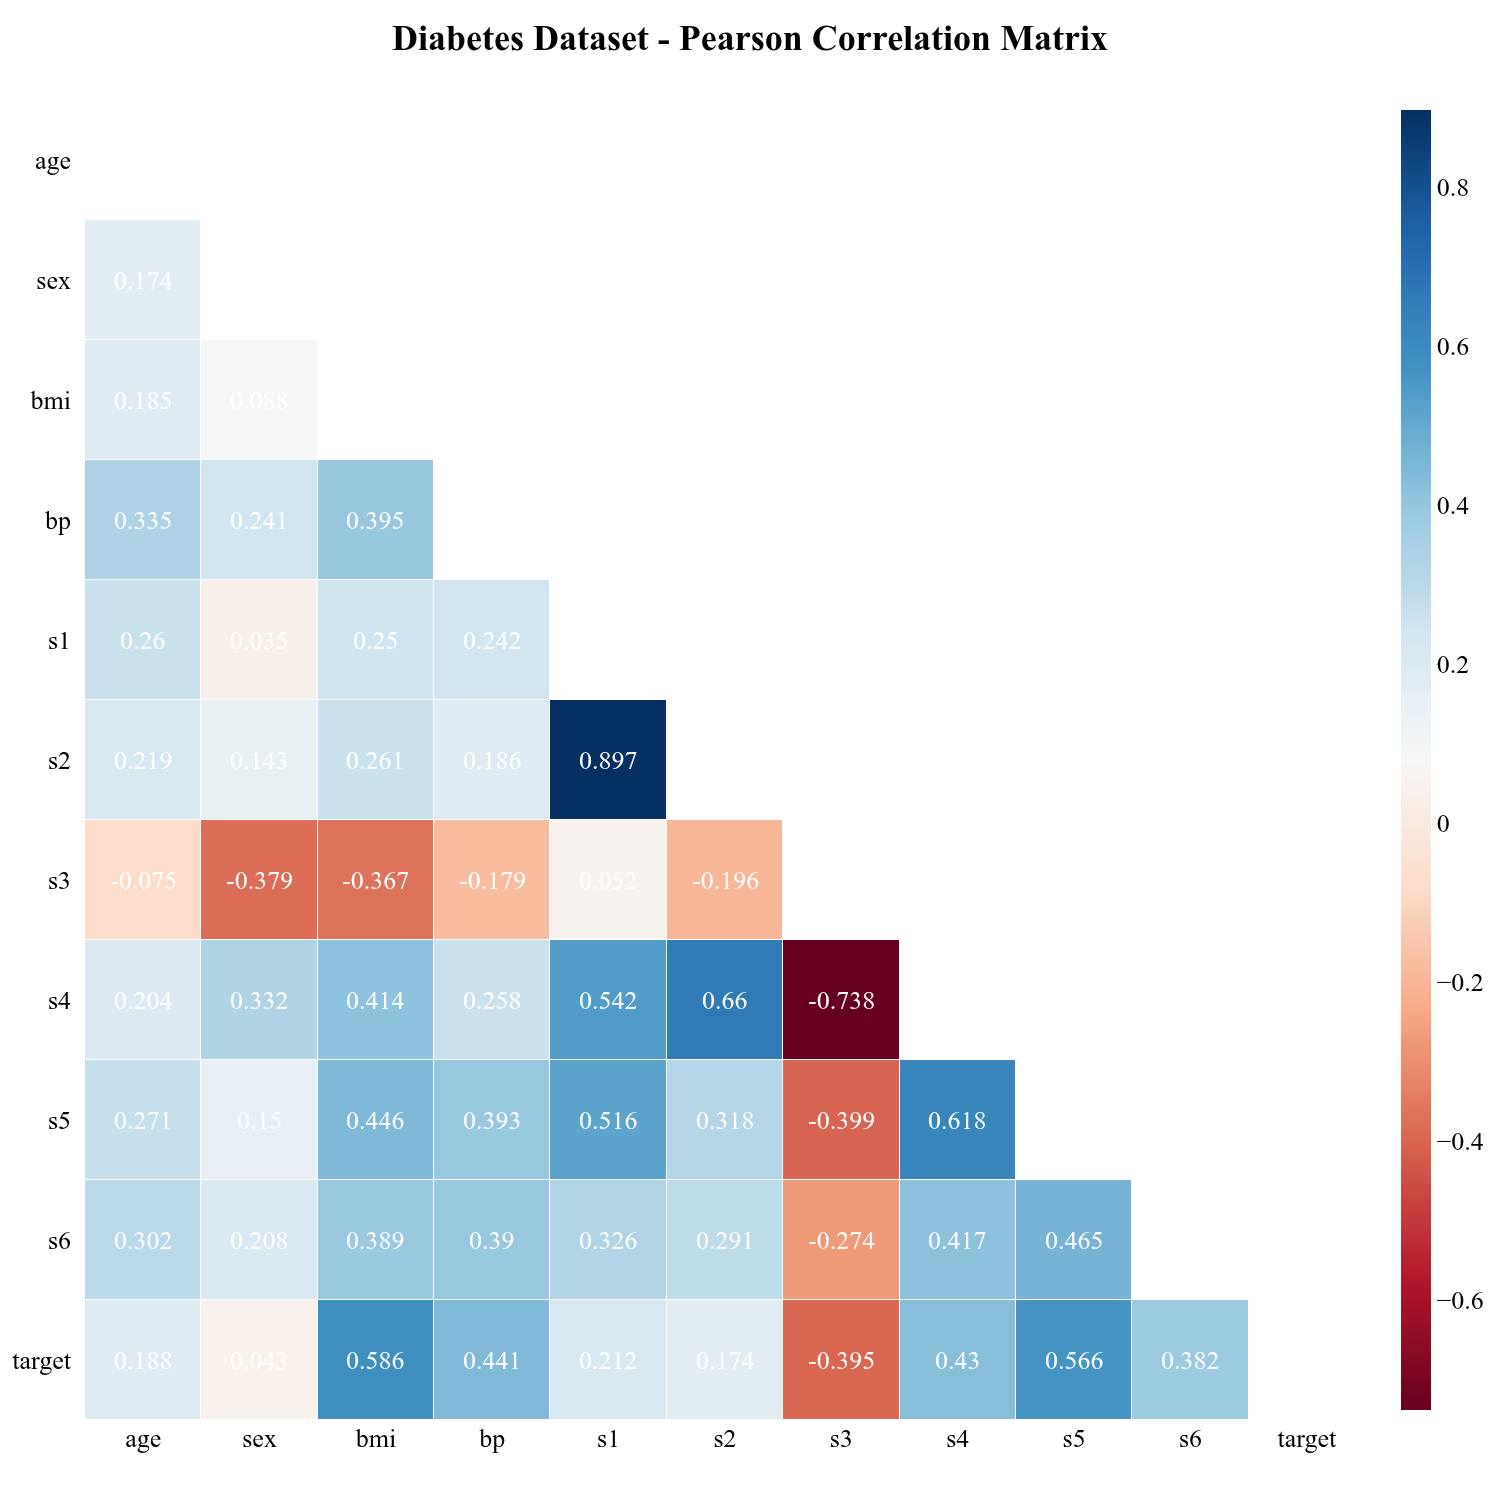

In [4]:
multi_plots.correlation_plot(
    data=diabetes_df[diabetes.feature_names + ['target']],
    features_names=list(diabetes.feature_names) + ['target'],
    method='pearson',
    plot_title="Diabetes Dataset - Pearson Correlation Matrix",
    width=1500,
    height=1500,
    show_upper=False,
    colorscale="RdBu"
)

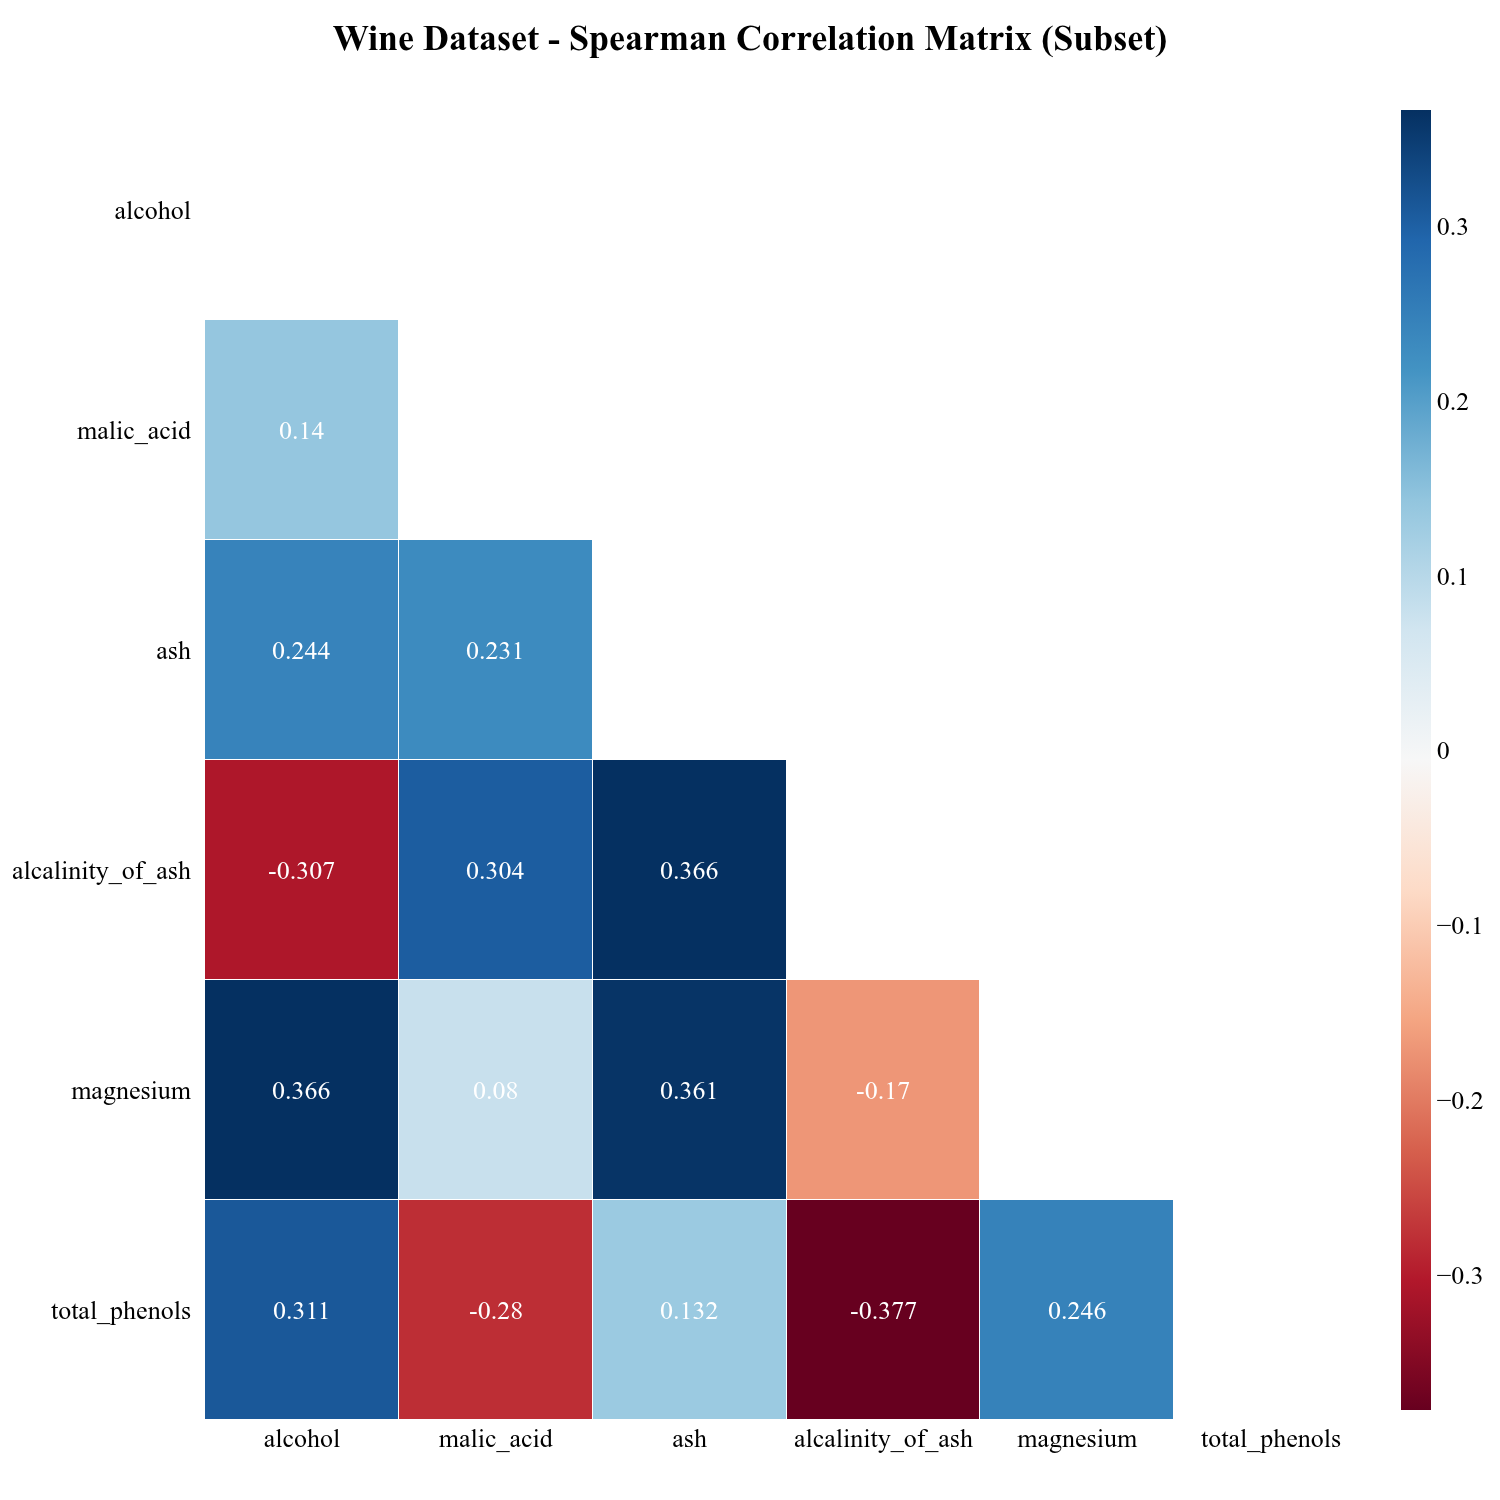

In [5]:
wine_subset = wine_df[['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']]

multi_plots.correlation_plot(
    data=wine_subset,
    features_names=list(wine_subset.columns),
    method='spearman',
    plot_title="Wine Dataset - Spearman Correlation Matrix (Subset)",
    width=1500,
    height=1500,
    show_upper=False,
    colorscale="RdBu"
)

## 3. scatter_matrix() - Pairwise Scatter Plots

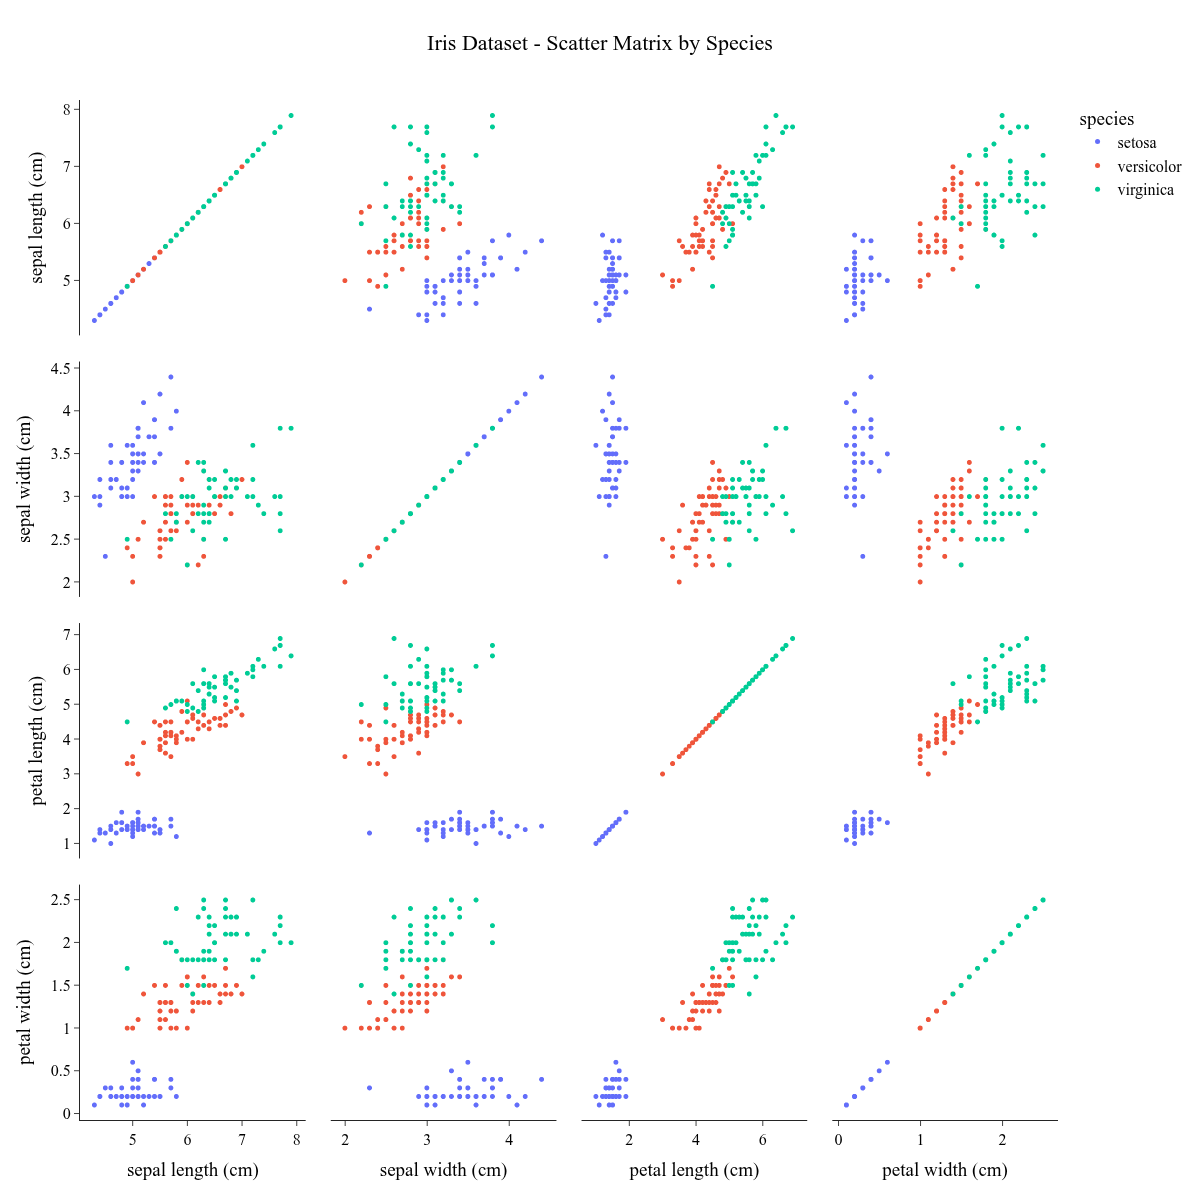

In [6]:
multi_plots.scatter_matrix(
    data=iris_df,
    features=list(iris.feature_names),
    hue='species',
    plot_title="Iris Dataset - Scatter Matrix by Species",
    width=1200,
    height=1200,
    marker_size=5,
)

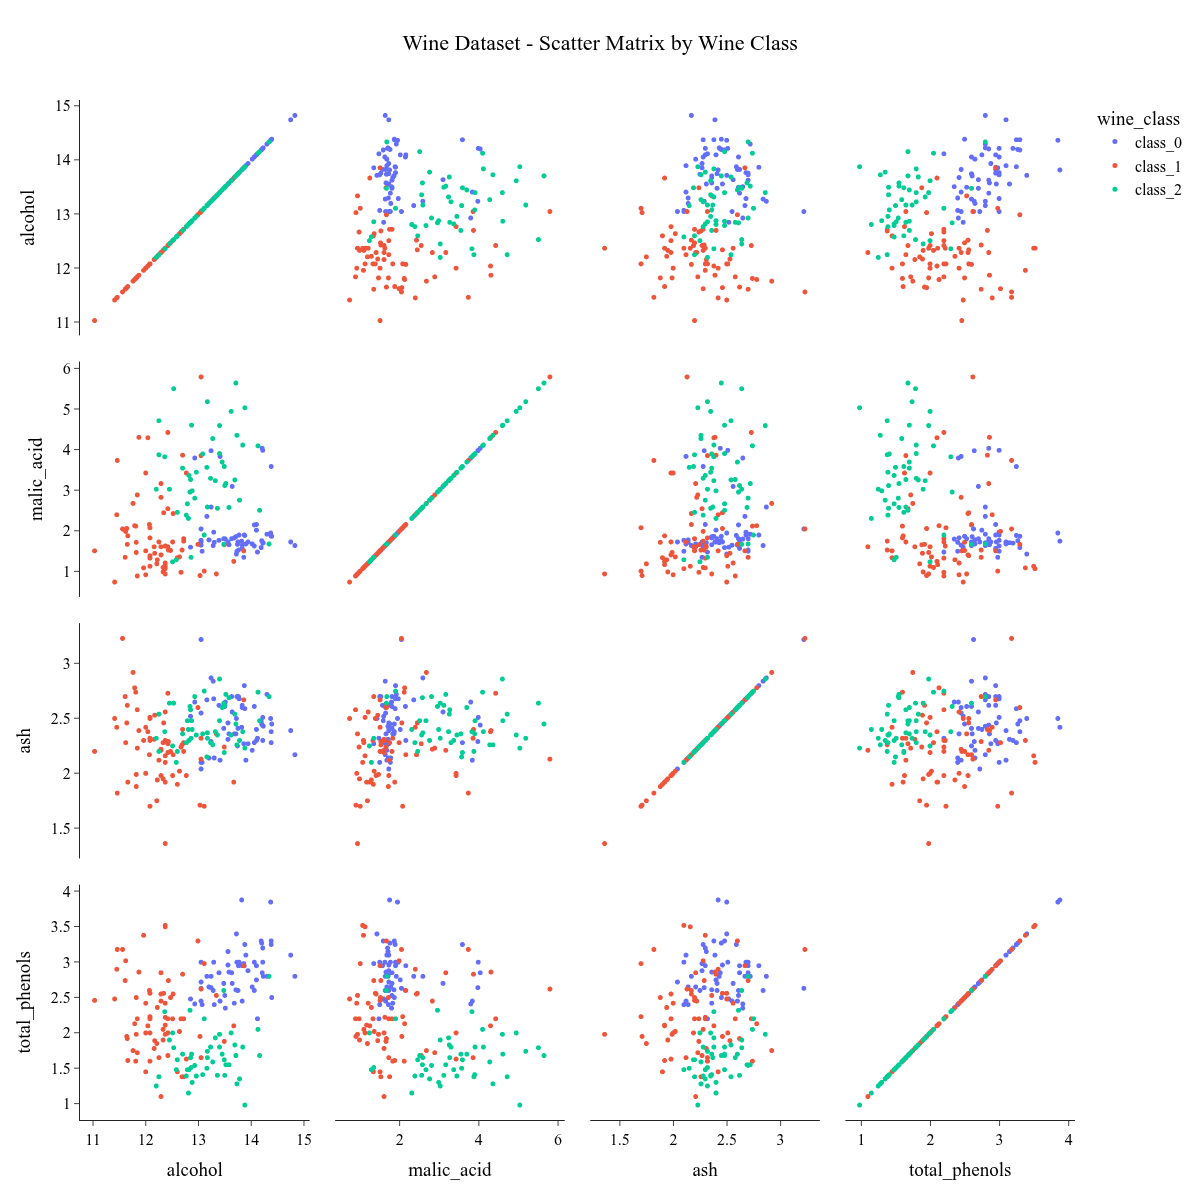

In [7]:
wine_features_for_scatter = ['alcohol', 'malic_acid', 'ash', 'total_phenols']

multi_plots.scatter_matrix(
    data=wine_df,
    features=wine_features_for_scatter,
    hue='wine_class',
    plot_title="Wine Dataset - Scatter Matrix by Wine Class",
    width=1200,
    height=1200,
    marker_size=5,
)

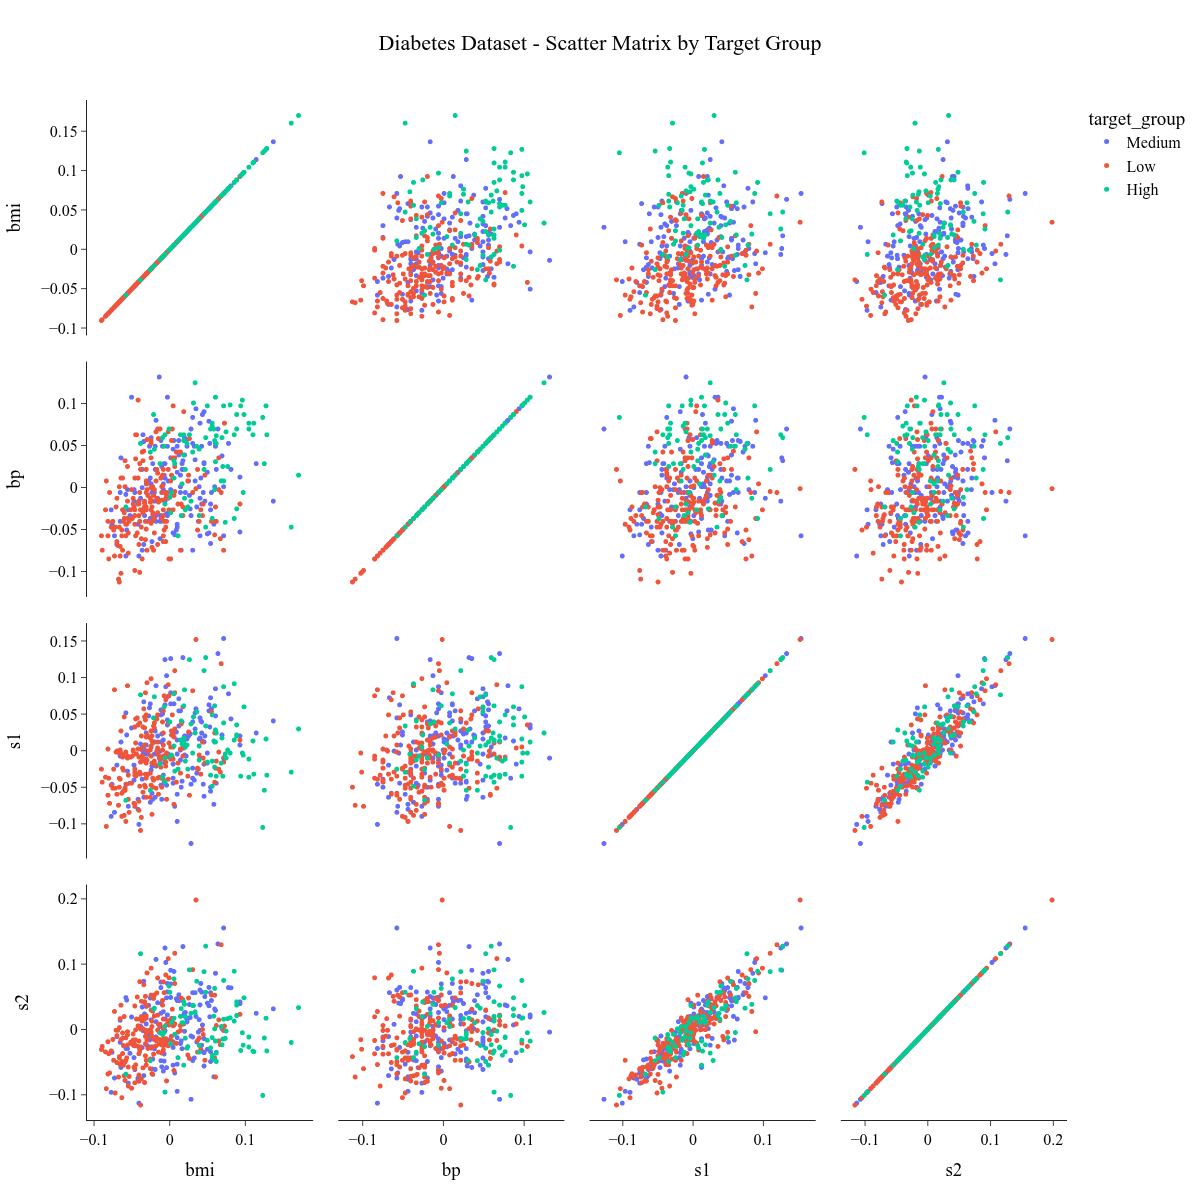

In [8]:
diabetes_features_for_scatter = ['bmi', 'bp', 's1', 's2']
diabetes_scatter = diabetes_df.copy()
diabetes_scatter['target_group'] = pd.cut(
    diabetes_df['target'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

multi_plots.scatter_matrix(
    data=diabetes_scatter,
    features=diabetes_features_for_scatter,
    hue='target_group',
    plot_title="Diabetes Dataset - Scatter Matrix by Target Group",
    width=1200,
    height=1200,
    marker_size=5,
)

## 4. parallel_coordinates() - Parallel Coordinates Plot

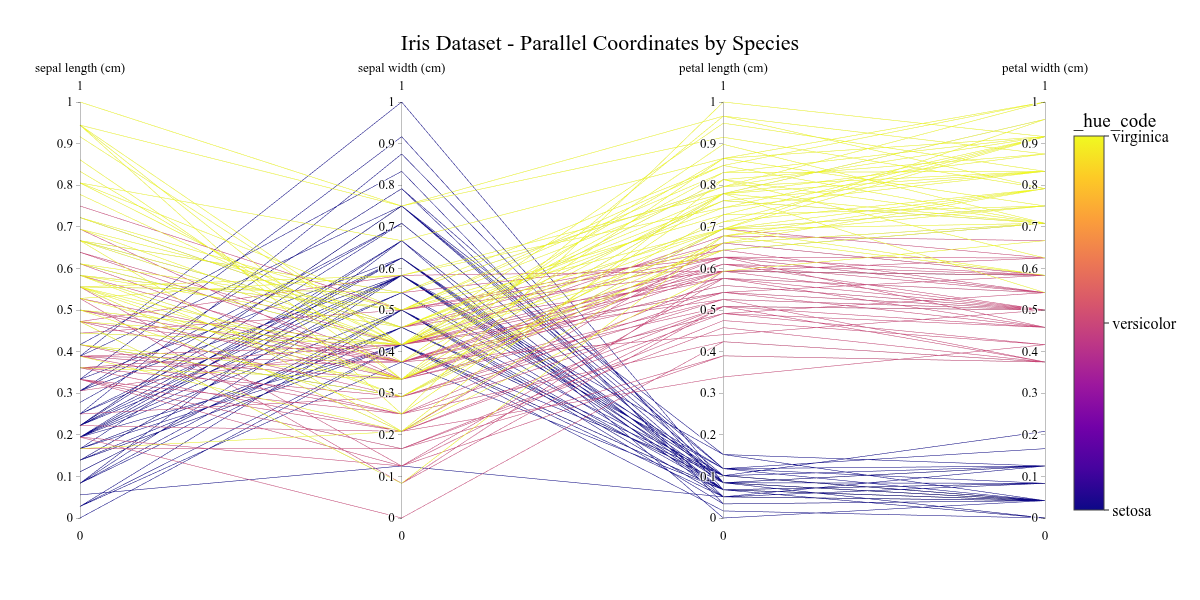

In [9]:
multi_plots.parallel_coordinates(
    data=iris_df,
    features=list(iris.feature_names),
    hue='species',
    plot_title="Iris Dataset - Parallel Coordinates by Species",
    width=1200,
    height=600,
    normalize=True
)

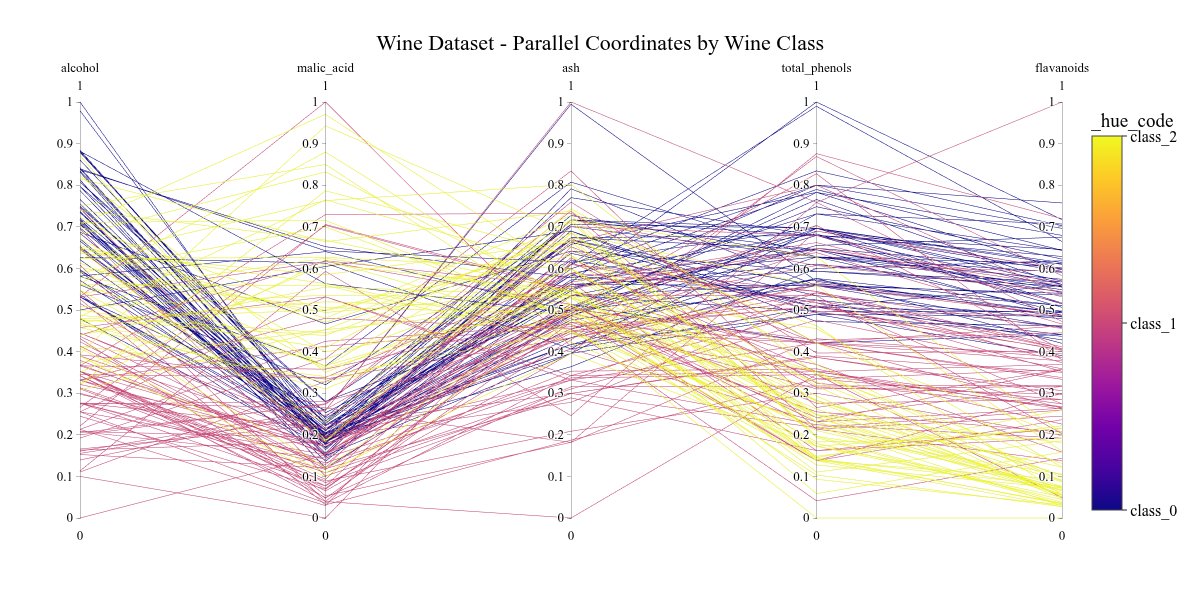

In [10]:
wine_parallel = wine_df[['alcohol', 'malic_acid', 'ash', 'total_phenols', 'flavanoids', 'wine_class']].copy()

multi_plots.parallel_coordinates(
    data=wine_parallel,
    features=['alcohol', 'malic_acid', 'ash', 'total_phenols', 'flavanoids'],
    hue='wine_class',
    plot_title="Wine Dataset - Parallel Coordinates by Wine Class",
    width=1200,
    height=600,
    normalize=True
)

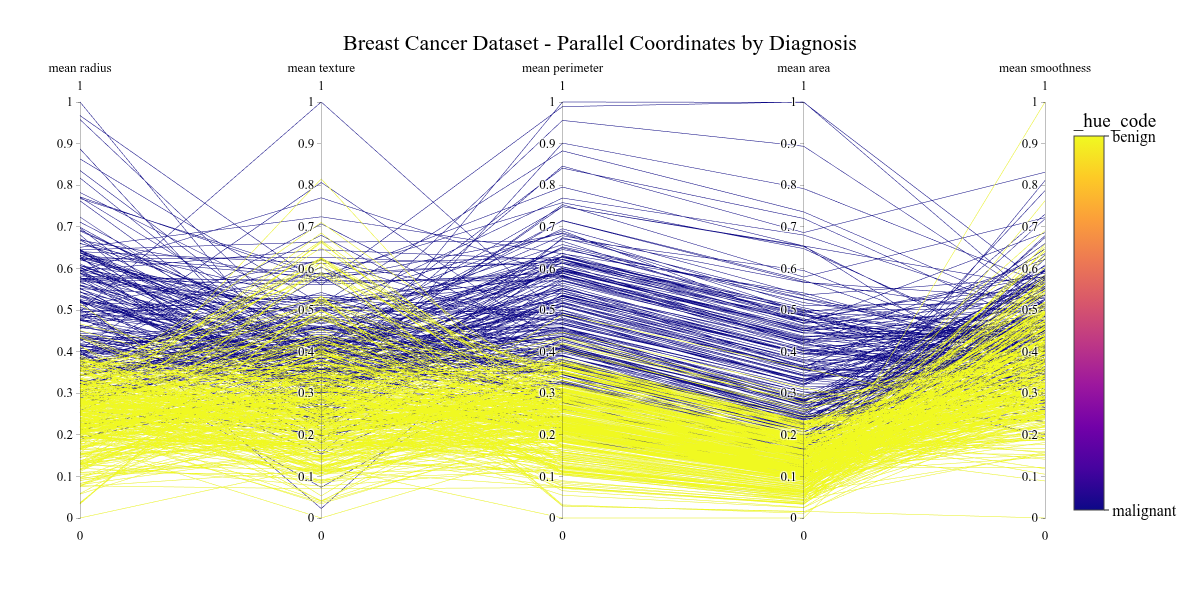

In [11]:
cancer_features_subset = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
cancer_parallel = cancer_df[cancer_features_subset + ['diagnosis']].copy()

multi_plots.parallel_coordinates(
    data=cancer_parallel,
    features=cancer_features_subset,
    hue='diagnosis',
    plot_title="Breast Cancer Dataset - Parallel Coordinates by Diagnosis",
    width=1200,
    height=600,
    normalize=True
)

## 5. heatmap() - Heatmap Visualization

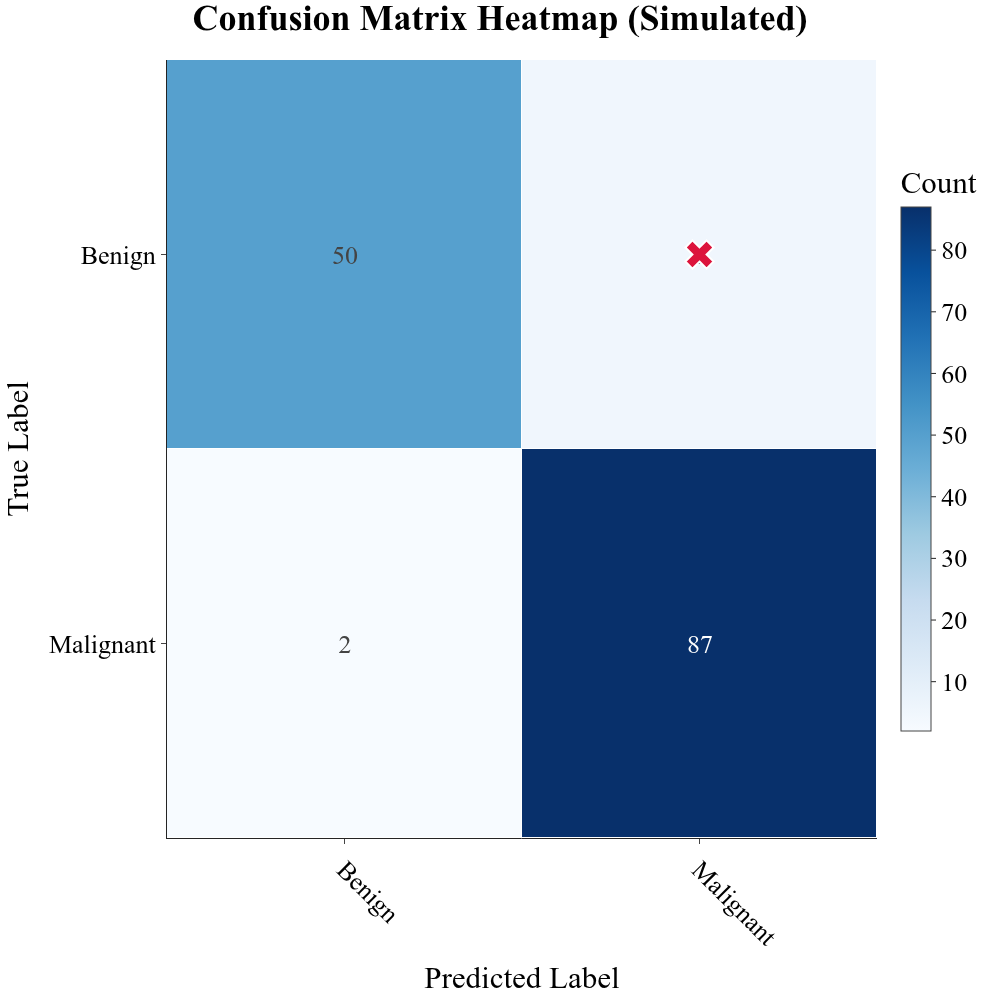

In [12]:
# Example: Heatmap of a confusion matrix for breast cancer dataset
import numpy as np
import pandas as pd

# Simulate a confusion matrix as a DataFrame
conf_matrix = np.array([[50, 2], [5, 87]])
conf_df = pd.DataFrame(conf_matrix, index=["Benign", "Malignant"], columns=["Benign", "Malignant"])

multi_plots.heatmap(
    data=conf_df,
    plot_title="Confusion Matrix Heatmap (Simulated)",
    width=1000,
    height=1000,
    xaxis_title="Predicted Label",
    yaxis_title="True Label",
    highlights=[("Malignant", "Benign")],
)

## 6. compare_distributions_plot() - Compare Distributions Before and After Imputation

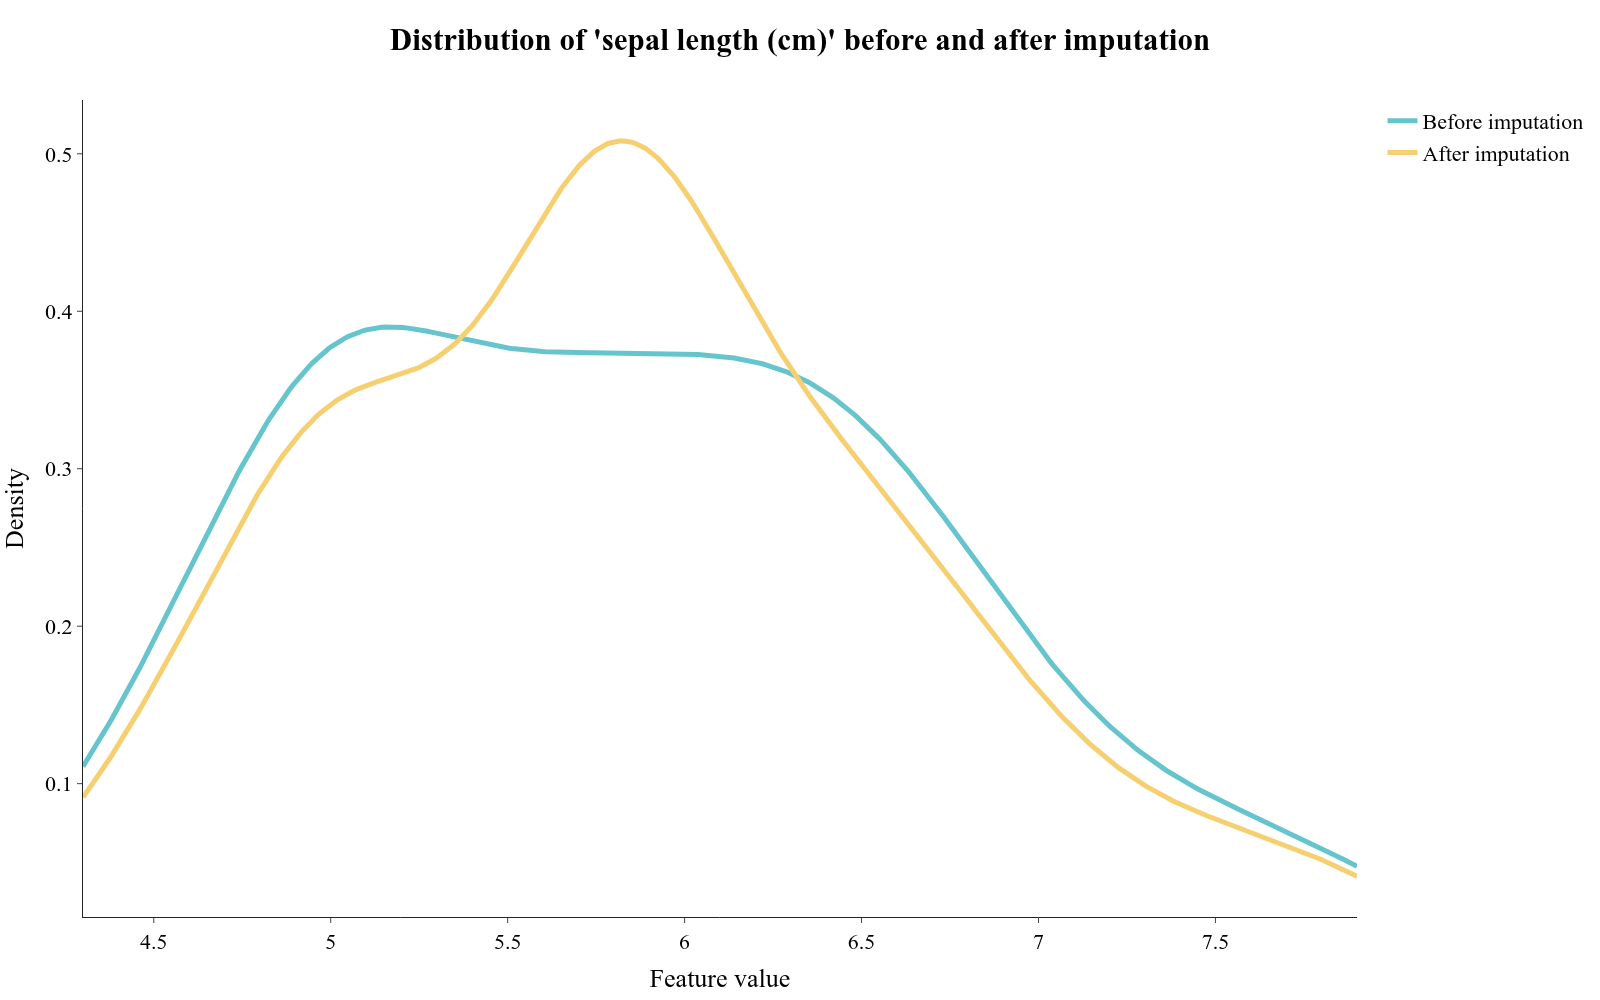

In [13]:
# Example: Compare distributions before and after imputation
import numpy as np
import pandas as pd

# Simulate missing values and imputation for a feature in iris_df
np.random.seed(42)
iris_df_missing = iris_df.copy()
missing_idx = np.random.choice(iris_df_missing.index, size=20, replace=False)
iris_df_missing.loc[missing_idx, 'sepal length (cm)'] = np.nan

# Impute missing values with the mean
imputed_values = iris_df_missing['sepal length (cm)'].fillna(iris_df_missing['sepal length (cm)'].mean())
iris_df_missing['sepal_length_imputed'] = imputed_values

multi_plots.compare_distributions_plot(
    df=iris_df_missing,
    feature_name='sepal length (cm)',
    imputed_col='sepal_length_imputed',
    categorical_columns=['species'],
    width=1600,
    height=1000,
)